In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# Read dataset
df = pd.read_csv("/content/AB_NYC_2019[1].csv")

In [ ]:
# Read  first 5 rows
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
# Read last 5 rows
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [ ]:
# Shape of dataset
print(df.shape)

(48895, 16)


In [ ]:
# Column names
print(df.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


In [ ]:
# Checking Data types
print(df.dtypes)

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [ ]:
# Checking for missing values
print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [ ]:
# Numerical columns
print(df.select_dtypes(include=['int64','float64']).columns)

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


In [ ]:
# Categorical columns
print(df.select_dtypes(include=['object']).columns)

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')


In [ ]:
# Drop last_review column
df.drop("last_review", axis=1, inplace=True)

In [ ]:
# Replace missing values with 0
df["reviews_per_month"].fillna(0, inplace=True)

/tmp/ipykernel_5162/1338295194.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["reviews_per_month"].fillna(0, inplace=True)


In [ ]:
# Drop columns which are identifiers
df.drop(["id","name","host_id","host_name"], axis=1, inplace=True)

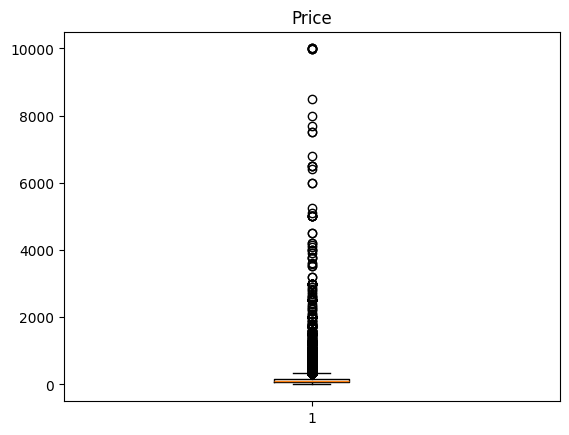

In [ ]:
# Boxplot for price
plt.boxplot(df["price"])
plt.title("Price")
plt.show()

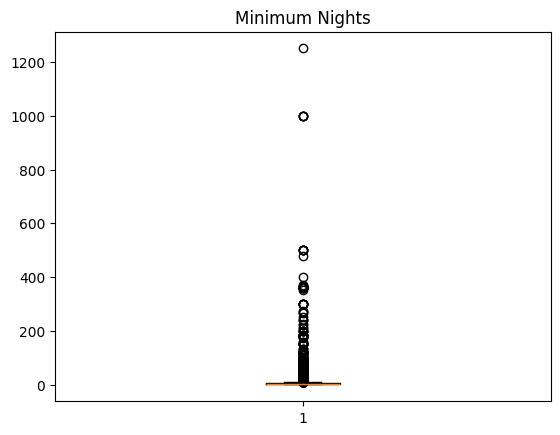

In [ ]:
# Boxplot for minimum nights
plt.boxplot(df["minimum_nights"])
plt.title("Minimum Nights")
plt.show()

In [ ]:
# Remove price outliers
price_limit = df["price"].quantile(0.95)
df = df[df["price"] <= price_limit]

In [ ]:
# Remove minimum night outliers
night_limit = df["minimum_nights"].quantile(0.95)
df = df[df["minimum_nights"] <= night_limit]

In [ ]:
# Drop neighbourhood because it has many unique values
df.drop("neighbourhood", axis=1, inplace=True)

In [ ]:
# Convert categorical columns into numbers
df = pd.get_dummies(df,columns=["neighbourhood_group","room_type"],drop_first=True)

In [ ]:
# Features
X = df.drop("price", axis=1)
# Target
y = df["price"]

In [ ]:
# Split dataset into train,test and validate
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
# Model creation
model = LinearRegression()
# Model training
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict values
y_pred = model.predict(X_test)

In [ ]:
# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

R2 Score : 0.47082773500021025


In [ ]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 38.5408749155387


In [ ]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

MSE : 2834.959378892661


In [ ]:
# Root Mean Squared Error
rmse = np.sqrt(mse)
print("RMSE :", rmse)

RMSE : 53.244336589844565


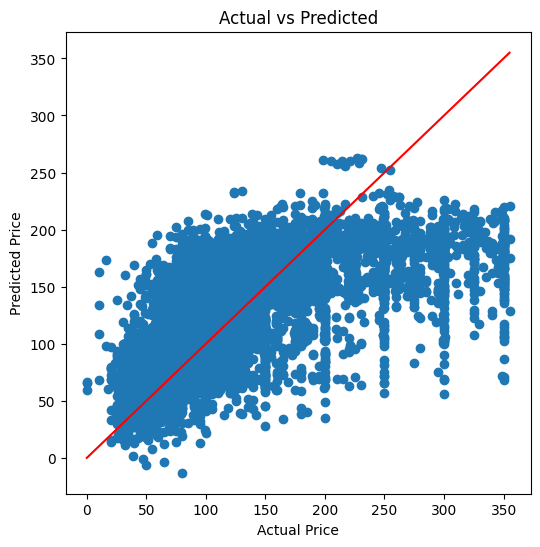

In [ ]:
# scatter plot of Actual Prices vs. Predicted Prices
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red")
plt.title("Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

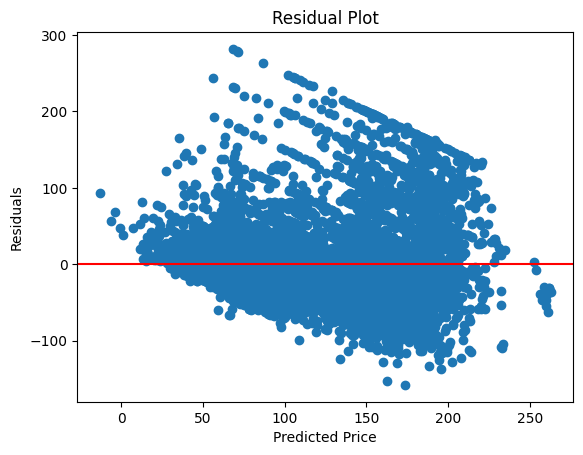

In [ ]:
#Residual Plot (Errors vs. Predicted values)
errors = y_test - y_pred
plt.scatter(y_pred, errors)
plt.axhline(y=0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

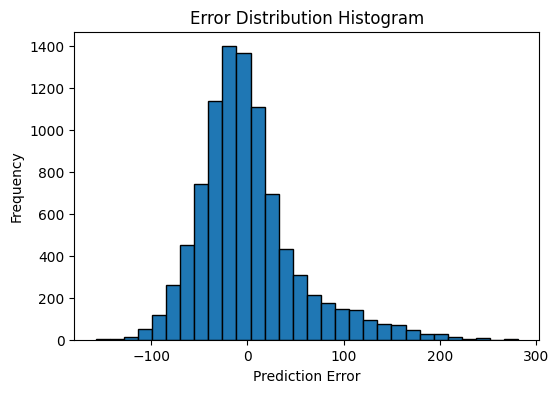

In [ ]:
# Error Distribution Histogram
plt.figure(figsize=(6,4))
plt.hist(errors, bins=30, edgecolor='black')
plt.title("Error Distribution Histogram")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()